This document has been completed individually. All work is the sole effort, unless otherwise noted, of myself Mason Wakefield.

# Introduction & System Selection 

For this report we will model an RC circuit with a fast transient. 

An RC circuit consists of a resistor R and capacitor C connected in series with an input voltage source. The variable of interest is the capacitor voltage V(t), which changes over time as the capacitor charges and discharges.

The governing ODE for this system is of the form:
$$\frac{dV}{dt} = -\frac{1}{RC}V + \frac{1}{RC}V_{\text{source}}(t)$$
We will define the parameters defined as follows:

| Parameter | Symbol | Value | Units | Description |
|-----------|--------|-------|-------|-------------|
| Resistance | R | 100 | Ω | Circuit resistance |
| Capacitance | C | 1e-9 | F | Capacitor value |
| Time Constant | RC | 1e-7 | s | Fast transient time |
| Initial Voltage | V(0) | 0 | V | Initially uncharged capacitor |
| Source Voltage | Vs(t) | 5 sin(t) | V | Slowly varying input |
| Angular Frequency | ω | 1 | rad/s | Slow forcing frequency |

We can rewrite the ODE in standard form with these parameters in mind like so:
$$\frac{dV}{dt} = -10^7V + 10^7 \cdot 5 \sin(t)$$

Note: This is a stiff ODE because the circuit responds in 0.1 microseconds, but the input signal varies over seconds, so the time scale ratio is $10^7$. We will also look at this ODE over a period of 10 seconds.

Resistance measures how strongly the resistor opposes electric current flow in the circuit. Larger resistance slows the charging and discharging of the capacitor. Capacitance represents the capacitor’s ability to store electric charge and energy in an electric field. A small capacitance allows the voltage to change very quickly. The time constant is the characteristic response time of the RC circuit. It indicates how quickly the capacitor voltage approaches the input voltage after a change. The initial voltage is the starting voltage across the capacitor at time t=0. A value of zero means the capacitor begins fully uncharged. The source voltage is the external driving voltage applied to the circuit. This sinusoidal input changes slowly over time and forces the circuit response. The angular frequency determines how fast the sinusoidal source voltage oscillates. A small value means the input varies slowly compared to the circuit transient response.

This RC circuit model is important in practice because resistor-capacitor networks are fundamental building blocks in modern electrical and electronic systems. They are widely used in applications such as digital circuits, high-speed electronics, sensor signal conditioning.

# Demonstration of Stiffness

Before we can demonstrate stiffness, we must first import the relevant libraries and define our ODE as a python function.

In [1]:
# Importing relevant libraries 
import numpy as np
import matplotlib.pyplot as plt

# Python function for our ODE
def dVdt(t, V):
    return(-10**7*V + 10**7 * 5 * np.sin(t))

Now, let's try to use the forward Euler method to solve this stiff ODE.

<ipython-input-2-780123d34e19>:15: RuntimeWarning: overflow encountered in double_scalars
  V_values[i] = V_n + h * (-1e7 * V_n + 1e7 * 5 * np.sin(t_n))
<ipython-input-2-780123d34e19>:15: RuntimeWarning: invalid value encountered in double_scalars
  V_values[i] = V_n + h * (-1e7 * V_n + 1e7 * 5 * np.sin(t_n))


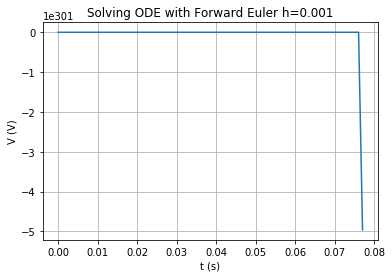

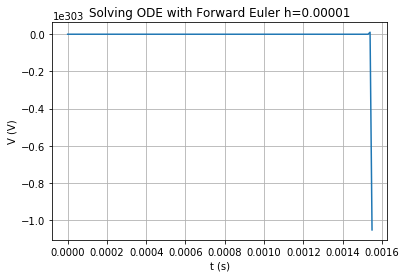

In [2]:
# Python function for the forward Euler method for this ODE
def ForwardEuler(h, t_start, t_end, V_0):
    # Time array
    t_values = np.arange(t_start, t_end + h, h)

    # Solution array
    V_values = np.zeros(len(t_values))
    V_values[0] = V_0

    # Forward Euler loop
    for i in range(1, len(t_values)):
        t_n = t_values[i - 1]
        V_n = V_values[i - 1]

        V_values[i] = V_n + h * (-1e7 * V_n + 1e7 * 5 * np.sin(t_n))

    return t_values, V_values

# Defining consistent parameters and initializing arrays
t_start = 0 # s
t_end = 10 # s
V_0 = 0 # V
t_values = []
V_values = []

# Running forward Euler with step size h=0.001
t_values, V_values = ForwardEuler(0.001, t_start, t_end, V_0)
plt.plot(t_values, V_values)
plt.title("Solving ODE with Forward Euler h=0.001")
plt.xlabel('t (s)')
plt.ylabel('V (V)')
plt.grid(True)
plt.show()

# Running forward Euler with step size h=0.00001
t_values, V_values = ForwardEuler(0.00001, t_start, t_end, V_0)
plt.plot(t_values, V_values)
plt.title("Solving ODE with Forward Euler h=0.00001")
plt.xlabel('t (s)')
plt.ylabel('V (V)')
plt.grid(True)
plt.show()

Notice how the plots collapsed and suffered overflow errors with the (somewhat) reasonable step sizes of h=.001 and h=0.00001. From the ODE, forward Euler would require a step size $h < \frac{2}{\lambda} = 2 \times 10^{-7}$. This would require forward Euler to calculate at least 50 million iterations over the 10 second time interval. The computational burden of forward Euler is too high for this stiff equation over the ten second time interval. This shows how implicit methods are necessary because explicit methods (such as forward Euler) are incapable of modeling this ODE properly using reasonable computational resources. Thus, we must use an implicit method such as backward Euler.

This stiff equation is linear because it is of the form:
$$\frac{dy}{dt} = -\lambda y + g(t)$$
Where:
$$-\lambda = -10^7$$

$$g(t) = 10^7 \sin(t)$$
When we try to find the stiffness ratio with eigenvalues, we run into trouble because there is only one eigenvalue $\lambda$ which is equal to $-10^7$. However, we can look at the time constants to make an estimate. The fast decay time scale $\tau_{fast} = \frac{1}{10^7}$ and the forcing time scale $\tau_{slow} \sim 1$. So, $$\text{stiffness ratio} \sim \frac{\tau_{slow}}{\tau_{fast}} = \frac{1}{10^{-7}} = 10^7$$ which makes this a stiff equation and explicit methods ineffective.

# Mathematical Setup 

The governing equation for the selected RC circuit is given by the stiff first-order ordinary differential equation
$$\frac{dV}{dt} = 10^{7}\big(5\sin(t) - V\big),$$
where $V(t)$ represents the capacitor voltage and the forcing term $5\sin(t)$ represents the applied sinusoidal source. This system is stiff due to the presence of the large parameter $10^{7}$, which introduces a very fast decay timescale compared to the slow variation of the input signal.
To apply the implicit Euler method, we first express the problem in the standard form $\frac{dy}{dt} = f(t,y)$, where in this case $y = V$ and
$$f(t,V) = 10^{7}(5\sin(t) - V).$$
The backward Euler discretization evaluates the function at the future time level, leading to the implicit update equation
$$V_{n+1} = V_n + h \cdot 10^{7}\big(5\sin(t_{n+1}) - V_{n+1}\big).$$
Since the unknown $V_{n+1}$ appears on both sides of the equation, this expression cannot be solved explicitly and must instead be reformulated as a root-finding problem.
To this end, we define the residual function
$$g(V_{n+1}) = V_{n+1} - V_n - h \cdot 10^{7}\big(5\sin(t_{n+1}) - V_{n+1}\big),$$
and seek the solution of
$$g(V_{n+1}) = 0.$$
This formulation converts the implicit Euler step into a nonlinear algebraic equation that must be solved at every time step.
Newton–Raphson iteration is used to solve this equation efficiently. The iterative update is given by
$$V_{n+1}^{(k+1)} = V_{n+1}^{(k)} - \frac{g\big(V_{n+1}^{(k)}\big)}{g'\big(V_{n+1}^{(k)}\big)},$$
where the derivative of the residual with respect to $V_{n+1}$ is
$$g'(V_{n+1}) = 1 + h \cdot 10^{7}.$$
A key simplification in this problem is that the derivative is constant, meaning it does not depend on the iteration index or the solution estimate. This significantly improves computational efficiency and stability of the Newton iteration.
For each time step, the initial guess for Newton’s method is taken as the explicit Euler predictor,
$$V_{n+1}^{(0)} = V_n + h f(t_n, V_n),$$
which provides a physically reasonable starting point and ensures rapid convergence. In practice, because the governing equation is linear in $V$, the Newton–Raphson method converges in a single iteration at each time step, making the implicit Euler method both stable and computationally efficient for this stiff system.

# Implementation

The function for our ODE can be found in Section 2: Demonstration of Stiffness. Now let's code up the other functions from the math above.

In [3]:
# Derivative df/dV is constant for this linear problem
def g_prime(h):
    return 1 + h * 1e7

# Newton-Raphson for single step with Backward Euler
def NewtonRaphson(f, V, t, h, tol=1e-6, max_iter=50):
    V_next = V + h * f(t, V)  # Explicit Euler predictor as initial guess
    for _ in range(max_iter):
        g_val = V_next - V - h * f(t + h, V_next)
        g_prime_val = g_prime(h)  # Constant derivative for this problem
        V_new = V_next - g_val / g_prime_val
        if abs(V_new - V_next) < tol:
            return V_new
        V_next = V_new
    return V_next

# Backward Euler function using Newton-Raphson steps
def BackwardEuler(f, V_0, t_start, t_end, h):
    # Initialize time steps and result array
    t_values = np.arange(t_start, t_end + h, h)
    V_values = np.zeros(len(t_values))
    V_values[0] = V_0
    
    # Iterate through time steps using Newton-Raphson to solve implicit step
    for i in range(1, len(t_values)):
        V_values[i] = NewtonRaphson(f, V_values[i-1], t_values[i-1], h)
    return t_values, V_values

# Results & Analysis

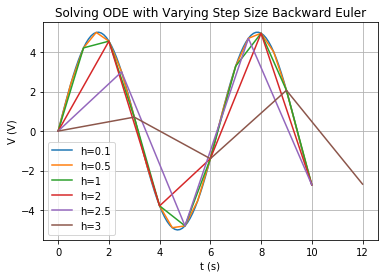

In [4]:
# Plotting backward Euler with varying step sizes
for h in [.1, .5, 1, 2, 2.5, 3]:
    t_values, V_values = BackwardEuler(dVdt, V_0, t_start, t_end, h)
    plt.plot(t_values, V_values, label = f'h={h}')
plt.legend()
plt.grid(True)
plt.title('Solving ODE with Varying Step Size Backward Euler')
plt.xlabel('t (s)')
plt.ylabel('V (V)')
plt.show()

From the plot above, we see how much more stable Euler's backward is for this stiff ODE. The largest stable step size is about h=2.5; anything larger than that is a seemingly random jagged line. This is many orders of magnitude larger than the maximum stable step size for Euler's forward. These results are further explained in the table below.

| Method                    | Stability Condition     | Max Stable Step Size ($h$)   | Constraint Note                          |
|:--------------------------|:------------------------|:-----------------------------|:-----------------------------------------|
| Forward Euler (Explicit)  | $h < \frac{2}{\lambda}$ | $2 \times 10^{-7}$           | Must be very small to prevent divergence |
| Backward Euler (Implicit) | Stable* for all $h > 0$  | $2.5$       | Limited only by accuracy, not stability  |

Note: The step sizes for backward Euler above 2.5 are technically stable, but not accurate or useful for our models.

Now, let's perform a Newton-Raphson convergence analysis to see what is going on within our functions. We will redefine the python functions to let us track the convergence.

Text(0.5, 1.0, 'Newton-Raphson Iterations per Time Step')

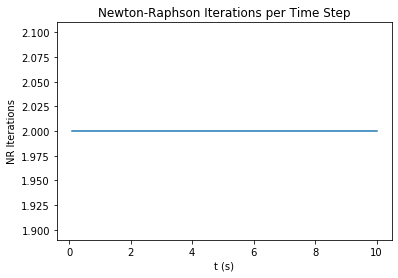

In [5]:
#Newton-Raphson now with tracking
def NewtonRaphson(f, V, t, h, tol=1e-6, max_iter=50):
    V_next = V + h * f(t, V)  # Explicit Euler predictor as initial guess
    for k in range(1, max_iter + 1):
        g_val = V_next - V - h * f(t + h, V_next)
        V_new = V_next - g_val / g_prime(h)
        if abs(V_new - V_next) < tol:
            return V_new, k   # return solution and iteration count
        V_next = V_new
    return V_next, max_iter   # hit max, return anyway

# Backward Euler now with tracking
def BackwardEuler(f, V_0, t_start, t_end, h):
    # Initialize time steps and result array
    t_values = np.arange(t_start, t_end + h, h)
    V_values = np.zeros(len(t_values))
    V_values[0] = V_0
    
    for i in range(1, len(t_values)):
        V_values[i], iters = NewtonRaphson(f, V_values[i-1], t_values[i-1], h)
        iteration_counts.append(iters)
    return t_values, V_values

#Run Euler's backward with reasonable step size h=.1
iteration_counts = []
t_values, V_values = BackwardEuler(dVdt, V_0, t_start, t_end, 0.1)

# PLotting Newton-Raphson iterations per time step
plt.plot(t_values[1:], iteration_counts)
plt.xlabel('t (s)')
plt.ylabel('NR Iterations')
plt.title('Newton-Raphson Iterations per Time Step')

We can see that the Newton-Raphson step converges almost immmediately, specifically on the second iteration. This is a constant value for the entire time and does not change. This happens because our governing ODE is linear; g is linear and g-prime is constant. Newton-Raphson will solve every step in two iterations, which is one of its strengths for ODEs of this type (technically 1 iteration but our code structure makes it 2).

What this means in practice is that each step of backward Euler is only calling two iterations of Newton-Raphson. With our step size of .1, which we previously saw produces a reasonable solution, this requires a total of 100 iterations of backward Euler and 200 iterations of Newton-Raphson, which is 300 total function calls. This is a laughable number of orders of magnitude better than forward Euler's 50 million required iterations, showing the usefulness of implicit methods for stiff ODEs.

So in summary, forward Euler requires a step size which is millions of times smaller and thus must call functions millions times more. This shows how explicit methods are impractical for modeling stiff ODEs.

# Performance Analysis

Let's see the performance of our backward Euler with different step sizes.

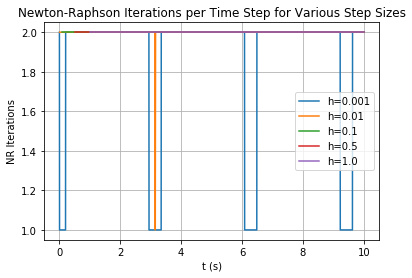

In [6]:
# Run backward Euler with varying h sizes
for h in [0.001, 0.01, 0.1, 0.5, 1.0]:
    iteration_counts = []
    t_vals, V_vals = BackwardEuler(dVdt, V_0, t_start, t_end, h)
    plt.plot(t_vals[1:], iteration_counts, label=f'h={h}')

# Plot the NR convergence for various step sizes
plt.xlabel('t (s)')
plt.ylabel('NR Iterations')
plt.title('Newton-Raphson Iterations per Time Step for Various Step Sizes')
plt.legend()
plt.grid(True)
plt.show()

From the plot, we can guess that the average number of Newton-Raphson iterations is about 1.8 for each backward Euler step. So, we can make the following table with that information in mind for each step size we tested. There are 10/h backward Euler steps in each model, about 1.8 Newton-Raphson iterations for each backward Euler step, and the sum of those function calls.

|   Step Size (h) |   BE Iterations |   NR Iterations |   Total Functions |
|----------------:|----------------:|----------------:|------------------:|
|           0.001 |           10000 |           18000 |             28000 |
|           0.01  |            1000 |            1800 |              2800 |
|           0.1   |             100 |             180 |               280 |
|           0.5   |              20 |              36 |                56 |
|           1     |              10 |              18 |                28 |

Notice that even with a needlessly small step size of .001, we still only run 28000 functions. This is still many orders of magnitude less than the bare minimum 50 million for forward Euler to be stable.

# Conclusions 

The biggest finding from our analyses is that implicit methods are far and away the best option for analyzing stiff ODEs. Explicit methods, such as Euler's forward or RK4, require too small of a step size to be stable when modeling stiff ODEs. Euler's backward, on the other hand, was able to move past the fast transient in our RC circuit and model the sinusoidal source voltage effect.

Practically, this means implicit methods should be used with stiff ODEs and explicit methods should be used for non-stiff ODEs.

The biggest challenge in this analysis was understanding exactly how the stiff ODE breaks explicit methods and why that's so significant. The tiny transient in our scenario make a world of difference to forward Euler and this was far from intuitive. However, by understanding that effect, the above conclusions can be drawn and lessons learned about implicit and explicit methods.